# Batch Normalization

신경망이 깊어질수록 각 층으로 들어가는 값의 분포가 불안정해질 수 있고, 그 결과 학습이 느리거나 흔들릴 수 있다.

Batch Normalization은 미니배치 단위의 평균과 분산을 사용해 값을 정규화한 뒤,
필요하면 다시 학습 가능한 스케일과 이동을 적용하는 층이다.

- 각 층으로 들어가는 값의 스케일을 너무 제멋대로 두지 않고
- 학습을 좀 더 안정적으로 진행하도록 돕는 장치
- 경우에 따라 더 큰 학습률 사용이나 빠른 수렴에 도움을 줄 수 있는 장치

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

torch.manual_seed(42)
np.random.seed(42)

## 1. BatchNorm

PyTorch의 `BatchNorm1d`는 학습 중 현재 배치의 평균과 분산으로 정규화하고,
동시에 running mean / running variance를 저장해 두었다가 평가 시 사용한다.  
또한 기본적으로 affine 파라미터를 가져서, 정규화 뒤에도 학습 가능한 스케일과 이동을 적용할 수 있다.

1. 학습 시: 현재 배치 통계량 사용
2. 평가 시: 학습 중 누적한 running 통계량 사용
3. 필요하면 학습 가능한 `gamma`, `beta`로 다시 조정

### 입력 정규화와 Batch Normalization의 차이

둘 다 **스케일을 다루는 것** 이라는 공통점이 있지만 역할이 다르다.

입력 정규화(Standardization 등)는
- 데이터셋의 입력값 자체를 미리 정리하는 전처리 단계이다.

Batch Normalization은
- 모델 내부 층 사이에 들어가며
- 학습 중 미니배치 통계량을 사용해 중간 표현을 조정한다.

즉,
- 입력 정규화는 데이터 준비 단계
- BatchNorm은 모델 내부의 층
이라고 구분하면 된다.

In [ ]:
x = torch.tensor([
    [1.0, 10.0, 100.0],
    [2.0, 20.0, 200.0],
    [3.0, 30.0, 300.0],
    [4.0, 40.0, 400.0],
])

bn = nn.BatchNorm1d(num_features=3)

bn.train()
y = bn(x)

print('input mean:', x.mean(dim=0))
print('input std:', x.std(dim=0, unbiased=False))
print()

# BatchNorm을 통과한 출력 y의 feature별 평균과 표준편차 확인
# train 모드에서는 현재 batch 기준으로 정규화 되므로 평균은 0에 가깝고 표준편차는 1에 가깝게 나온다.
print('output mean:', y.mean(dim=0))
print('output std:', y.std(dim=0, unbiased=False))
print()

# running_mean, running_var는 평가 모드에서 사용할 통계량
# train 중 매 batch마다 조금씩 누적 업데이트 한다.
# new = (1 - momentum) * old + momentum * current_batch
print('running_mean:', bn.running_mean)
print('running_var:', bn.running_var)

input mean: tensor([  2.5000,  25.0000, 250.0000])
input std: tensor([  1.1180,  11.1803, 111.8034])

output mean: tensor([ 8.9407e-08,  1.4901e-07, -2.9802e-08], grad_fn=<MeanBackward1>)
output std: tensor([1.0000, 1.0000, 1.0000], grad_fn=<StdBackward0>)

running_mean: tensor([ 0.2500,  2.5000, 25.0000])
running_var: tensor([1.0667e+00, 1.7567e+01, 1.6676e+03])


## 2. train 모드와 eval 모드 차이

BatchNorm은 dropout과 마찬가지로 `train()` / `eval()`에 따라 동작이 달라진다.

- `train()`에서는 현재 배치의 평균/분산 사용
- `eval()`에서는 저장된 running mean / running variance 사용

따라서 BatchNorm이 있는 모델도 검증/테스트/추론 시 `model.eval()`이 꼭 필요하다.

In [5]:
batch1 = torch.tensor([
    [1.0, 10.0, 100.0],
    [2.0, 20.0, 200.0],
    [3.0, 30.0, 300.0],
    [4.0, 40.0, 400.0],
])

batch2 = torch.tensor([
    [10.0, 100.0, 1000.0],
    [11.0, 110.0, 1100.0],
    [12.0, 120.0, 1200.0],
    [13.0, 130.0, 1300.0],
])

bn = nn.BatchNorm1d(num_features=3)

# train 모드에서는 현재 배치 통계량을 사용한다.
bn.train()
_ = bn(batch1)
train_out = bn(batch2)

# eval 모드에서는 저장 된 running stats를 사용한다.
bn.eval()
eval_out = bn(batch2)

print('train mode output')
print(train_out)
print()

print('eval mode output')
print(eval_out)
print()

print('running mean:', bn.running_mean)
print('running var:', bn.running_var)

train mode output
tensor([[-1.3416, -1.3416, -1.3416],
        [-0.4472, -0.4472, -0.4472],
        [ 0.4472,  0.4472,  0.4472],
        [ 1.3416,  1.3416,  1.3416]], grad_fn=<NativeBatchNormBackward0>)

eval mode output
tensor([[ 8.1257, 15.1347, 15.3251],
        [ 9.0678, 16.8894, 17.1019],
        [10.0099, 18.6442, 18.8787],
        [10.9520, 20.3989, 20.6555]], grad_fn=<NativeBatchNormBackward0>)

running mean: tensor([  1.3750,  13.7500, 137.5000])
running var: tensor([1.1267e+00, 3.2477e+01, 3.1675e+03])


## 3. 실습

MLP에서는 보통 다음과 같이 자주 쓴다.

`Linear -> BatchNorm1d -> ReLU`

즉,
1. 선형 변환 결과를 만들고
2. 그 값을 BatchNorm으로 정리한 뒤
3. 활성화 함수를 통과시키는 흐름이다.

In [6]:
# 데이터 생성
X, y = make_moons(n_samples=1000, noise=0.35, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
y_train = torch.tensor(y_train.reshape(-1, 1), dtype=torch.float32)
y_val = torch.tensor(y_val.reshape(-1, 1), dtype=torch.float32)

# BatchNorm은 mini-batch 통계량을 사용하므로 너무 작은 batch보다 어느정도 크기가 있는 batch가 비교하기 쉽다
train_loader = DataLoader(
    TensorDataset(X_train, y_train),
    batch_size=128,
    shuffle=True
)

In [7]:
class DeepMLPWithoutBN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )
    def forward(self, x):
        return self.net(x)
    
class DeepMLPWithBN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )
    def forward(self, x):
        return self.net(x)

In [8]:
def train_binary_model(model, train_loader, X_train, y_train, X_val, y_val, epochs=150, lr=0.1):
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)

    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []

    for epoch in range(epochs):
        model.train()

        epoch_loss_sum = 0.0        # epoch 동안 batch loss 누적
        epoch_correct = 0           # epoch 동안 맞춘 sample 수 누적
        epoch_total = 0             # epoch 동안 본 전체 sample 수 누적

        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            logits = model(batch_X)
            loss = criterion(logits, batch_y)
            loss.backward()
            optimizer.step()

            # loss는 batch 평균 값이므로 batch 크기를 곱해 전체 sample 기준 합처럼 누적
            epoch_loss_sum += loss.item() * batch_X.size(0)

            pred = (torch.sigmoid(logits) >= 0.5).float()
            epoch_correct += (pred == batch_y).sum().item()
            epoch_total += batch_y.size(0)
        
        # train 성능은 학습 중 mini-batch 결과를 누적해 계산
        train_loss = epoch_loss_sum / epoch_total
        train_acc = epoch_correct / epoch_total

        # validation은 가중치 업데이트 없이 성능만 확인
        model.eval()
        with torch.no_grad():
            val_logits = model(X_val)
            val_loss = criterion(val_logits, y_val).item()
            val_pred = (torch.sigmoid(val_logits) >= 0.5).float()
            val_acc = (val_pred == y_val).float().mean().item()

        train_losses.append(train_loss)
        train_accs.append(train_acc)
        val_losses.append(val_loss)
        val_accs.append(val_acc)
    
    return train_losses, val_losses, train_accs, val_accs


In [9]:
torch.manual_seed(42)
model_no_bn = DeepMLPWithoutBN()

torch.manual_seed(42)
model_with_bn = DeepMLPWithBN()

hist_no = train_binary_model(model_no_bn, train_loader, X_train, y_train, X_val, y_val, epochs=150, lr=0.1)
hist_bn = train_binary_model(model_with_bn, train_loader, X_train, y_train, X_val, y_val, epochs=150, lr=0.1)

no_train_loss, no_val_loss, no_train_acc, no_val_acc = hist_no
bn_train_loss, bn_val_loss, bn_train_acc, bn_val_acc = hist_bn

print('without batch norm - final train acc:', round(no_train_acc[-1], 4))
print('without batch norm - final val acc:', round(no_val_acc[-1], 4))
print()
print('with batch norm - final train acc:', round(bn_train_acc[-1], 4))
print('with batch norm - final val acc:', round(bn_val_acc[-1], 4))

without batch norm - final train acc: 0.892
without batch norm - final val acc: 0.896

with batch norm - final train acc: 0.8867
with batch norm - final val acc: 0.908


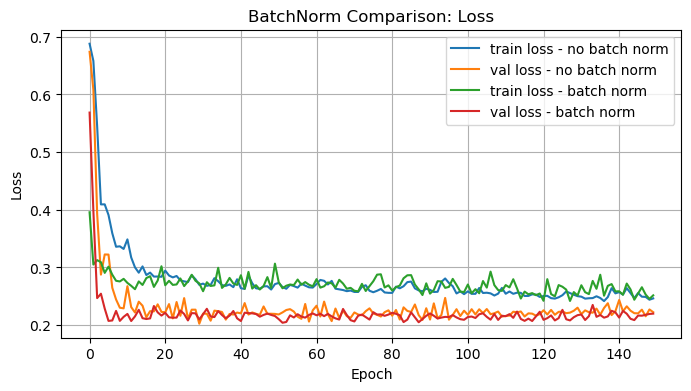

In [10]:
# loss 비교 그래프
plt.figure(figsize=(8, 4))
plt.plot(no_train_loss, label='train loss - no batch norm')
plt.plot(no_val_loss, label='val loss - no batch norm')
plt.plot(bn_train_loss, label='train loss - batch norm')
plt.plot(bn_val_loss, label='val loss - batch norm')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('BatchNorm Comparison: Loss')
plt.legend()
plt.grid()
plt.show()

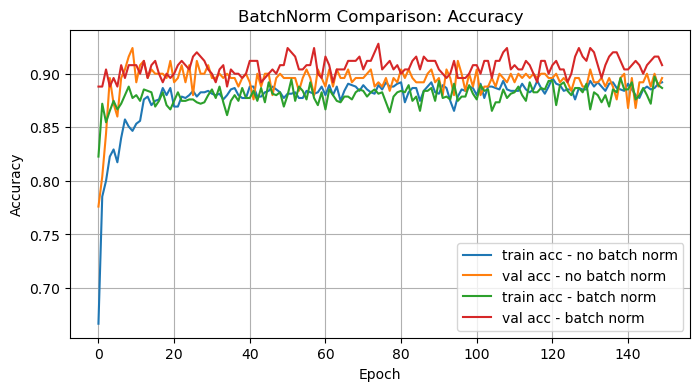

In [12]:
# accuracy 비교 그래프
plt.figure(figsize=(8, 4))
plt.plot(no_train_acc, label='train acc - no batch norm')
plt.plot(no_val_acc, label='val acc - no batch norm')
plt.plot(bn_train_acc, label='train acc - batch norm')
plt.plot(bn_val_acc, label='val acc - batch norm')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('BatchNorm Comparison: Accuracy')
plt.legend()
plt.grid()
plt.show()

## 정리

1. Batch Normalization은 층 사이의 값을 미니배치 기준으로 정규화하는 층이다.
2. 학습 시에는 현재 배치의 평균/분산을 사용하고, 평가 시에는 running 통계량을 사용한다. 
3. 입력 정규화는 데이터 전처리이고, BatchNorm은 모델 내부 층이다.
4. BatchNorm은 학습을 더 안정적으로 만드는 데 도움을 줄 수 있다.
5. BatchNorm이 있는 모델도 검증/추론 시 `model.eval()`이 매우 중요하다. 